# Module 1.8 — 1D Burgers' Equation

The **Burgers' equation** is the simplest PDE that combines **nonlinear convection** and **diffusion**:

$$\boxed{\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}}$$

| Term | Role |
|------|------|
| $u\,\partial u/\partial x$ | Nonlinear convection — $u$ is its own wave speed → steepens gradients → **shocks** |
| $\nu\,\partial^2 u/\partial x^2$ | Diffusion / viscosity — smooths gradients → **opposes shocks** |

**Why it matters:** Burgers' equation is the 1D "test bed" for Navier-Stokes. It has the same nonlinear convection term $u\cdot\nabla u$ that makes NS hard. Everything you learn here carries directly to Module 2.

## Two Limiting Cases

| Case | Equation | Behaviour |
|------|----------|-----------|
| **Inviscid** ($\nu=0$) | $\partial u/\partial t + u\,\partial u/\partial x = 0$ | Shock forms in finite time |
| **Viscous** ($\nu>0$) | full equation | Diffusion smooths the shock; sharpness ∝ $1/Re$ |

Reynolds number: $Re = UL/\nu$ — high $Re$ = sharp shock, low $Re$ = smooth spreading.

## 1. Setup

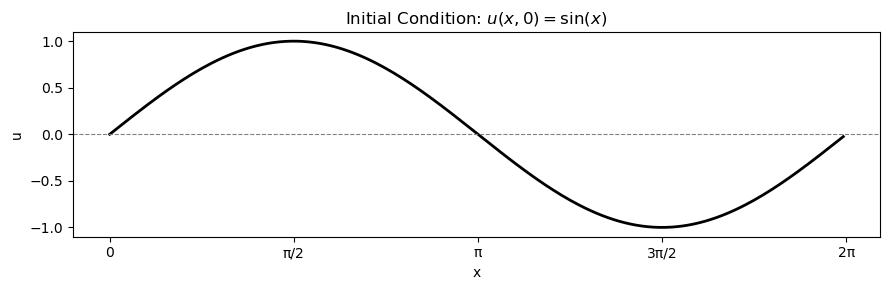

The positive half (0 to π) will steepen toward the right.
The negative half (π to 2π) will steepen toward the left.
Both create shocks — they meet and annihilate at π and 2π.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# ── Domain ────────────────────────────────────────────────────────────────────
L  = 2 * np.pi   # domain [0, 2π] — standard for Burgers demos
N  = 256         # grid points
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)   # periodic grid

# ── Initial condition: a smooth sine wave ─────────────────────────────────────
# u(x, 0) = sin(x)  — tall part (near π/2) will overtake shorter part ahead
def u_init(x):
    return np.sin(x)

u0 = u_init(x)

plt.figure(figsize=(9, 3))
plt.plot(x, u0, "k-", lw=2)
plt.axhline(0, color="gray", lw=0.8, ls="--")
plt.title("Initial Condition: $u(x,0) = \\sin(x)$", fontsize=12)
plt.xlabel("x"); plt.ylabel("u")
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ["0", "π/2", "π", "3π/2", "2π"])
plt.tight_layout(); plt.show()

print("The positive half (0 to π) will steepen toward the right.")
print("The negative half (π to 2π) will steepen toward the left.")
print("Both create shocks — they meet and annihilate at π and 2π.")

## 2. Inviscid Burgers ($\nu = 0$) — Shock Formation

With $\nu = 0$ the equation becomes:
$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0$$

The discretization uses **upwind for the nonlinear term** — same principle as Module 1.6, but now the "wave speed" at each point is $u_i^n$ itself:

$$u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x}\,u_i^n\,(u_i^n - u_{i-1}^n) \quad \text{when } u_i^n > 0$$

For general sign, the **general upwind** (from Module 1.6):

$$u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x}\left[\max(u_i^n, 0)(u_i^n - u_{i-1}^n) + \min(u_i^n, 0)(u_{i+1}^n - u_i^n)\right]$$

**Shock formation time** for $u_0(x) = \sin(x)$: the steepest descent of the initial condition is at $x = \pi$ where $du_0/dx = -1$. The shock forms at:
$$t_s = \frac{-1}{\min(du_0/dx)} = \frac{1}{1} = 1$$

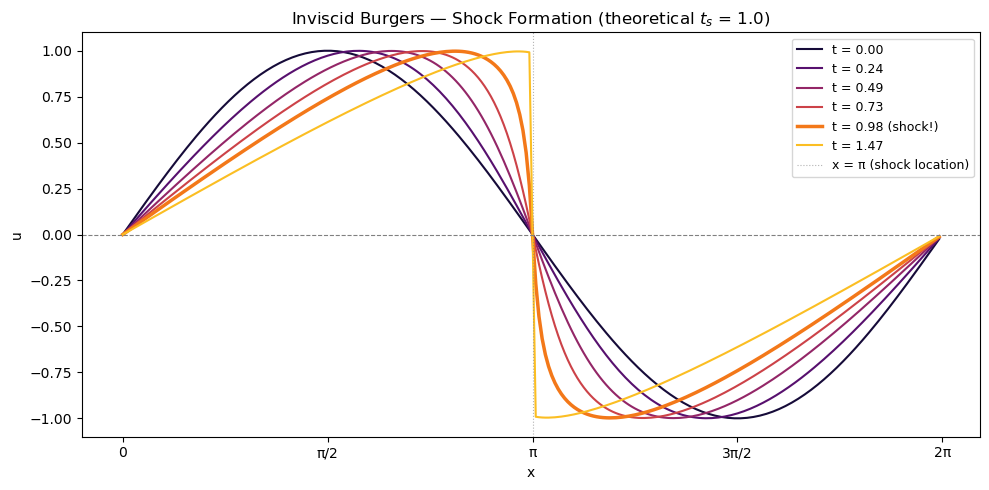

dt = 0.01963,  steps to shock = 50
Notice: the wave steepens at x=π until it becomes nearly vertical — that's the shock.
After t_s, the numerical solution continues but the physics has become multi-valued.


In [9]:
def burgers_inviscid(u0, dx, dt, nt, save_at=None):
    """
    Inviscid Burgers: du/dt + u * du/dx = 0
    Uses general upwind: max(u,0)*FTBS + min(u,0)*FTFS
    Periodic boundary conditions via np.roll.
    """
    u = u0.copy()
    snapshots = {0: u.copy()}

    for n in range(1, nt + 1):
        u_left  = np.roll(u,  1)   # u_{i-1}
        u_right = np.roll(u, -1)   # u_{i+1}

        # General upwind: look upstream based on sign of u at each point
        flux = (np.maximum(u, 0) * (u - u_left) +
                np.minimum(u, 0) * (u_right - u))
        u = u - (dt / dx) * flux

        if save_at and n in save_at:
            snapshots[n] = u.copy()

    return snapshots

# ── Time step: satisfy CFL using max(|u|) = 1 for sin(x) ─────────────────────
cfl  = 0.8
dt   = cfl * dx / 1.0     # max|u0| = 1
t_shock = 1.0             # theoretical shock time
nt_shock = int(t_shock / dt)

# Save snapshots at 0%, 25%, 50%, 75%, 100% of t_shock
save_steps = [0, nt_shock//4, nt_shock//2, 3*nt_shock//4, nt_shock,
              int(1.5 * nt_shock)]
snaps = burgers_inviscid(u0, dx, dt, max(save_steps), save_at=set(save_steps))

# ── Plot shock formation ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.inferno(np.linspace(0.1, 0.85, len(save_steps)))
labels = [f"t = {s*dt:.2f}" + (" (shock!)" if s == nt_shock else "") for s in save_steps]

for step, color, label in zip(save_steps, colors, labels):
    if step in snaps:
        lw = 2.5 if step == nt_shock else 1.5
        ax.plot(x, snaps[step], color=color, lw=lw, label=label)

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(np.pi, color="gray", lw=0.8, ls=":", alpha=0.6, label="x = π (shock location)")
ax.set_title(f"Inviscid Burgers — Shock Formation (theoretical $t_s$ = {t_shock})", fontsize=12)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"])
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

print(f"dt = {dt:.5f},  steps to shock = {nt_shock}")
print("Notice: the wave steepens at x=π until it becomes nearly vertical — that's the shock.")
print("After t_s, the numerical solution continues but the physics has become multi-valued.")

## 3. Viscous Burgers — Convection vs Diffusion

Now add viscosity $\nu > 0$. The full discretization:

$$u_i^{n+1} = u_i^n
  \underbrace{- \frac{\Delta t}{\Delta x}\left[\max(u_i^n,0)(u_i^n - u_{i-1}^n) + \min(u_i^n,0)(u_{i+1}^n - u_i^n)\right]}_{\text{nonlinear convection (upwind)}}
  + \underbrace{\frac{\nu\Delta t}{\Delta x^2}(u_{i+1}^n - 2u_i^n + u_{i-1}^n)}_{\text{diffusion (central)}}$$

**Two stability conditions must BOTH hold:**
$$\text{CFL} = \frac{u_{\max}\Delta t}{\Delta x} \leq 1 \qquad \text{AND} \qquad r = \frac{\nu\Delta t}{\Delta x^2} \leq \frac{1}{2}$$

We pick $\Delta t = \min\!\left(\frac{\text{CFL}\cdot\Delta x}{u_{\max}},\ \frac{0.4\,\Delta x^2}{\nu}\right)$ to satisfy both automatically.

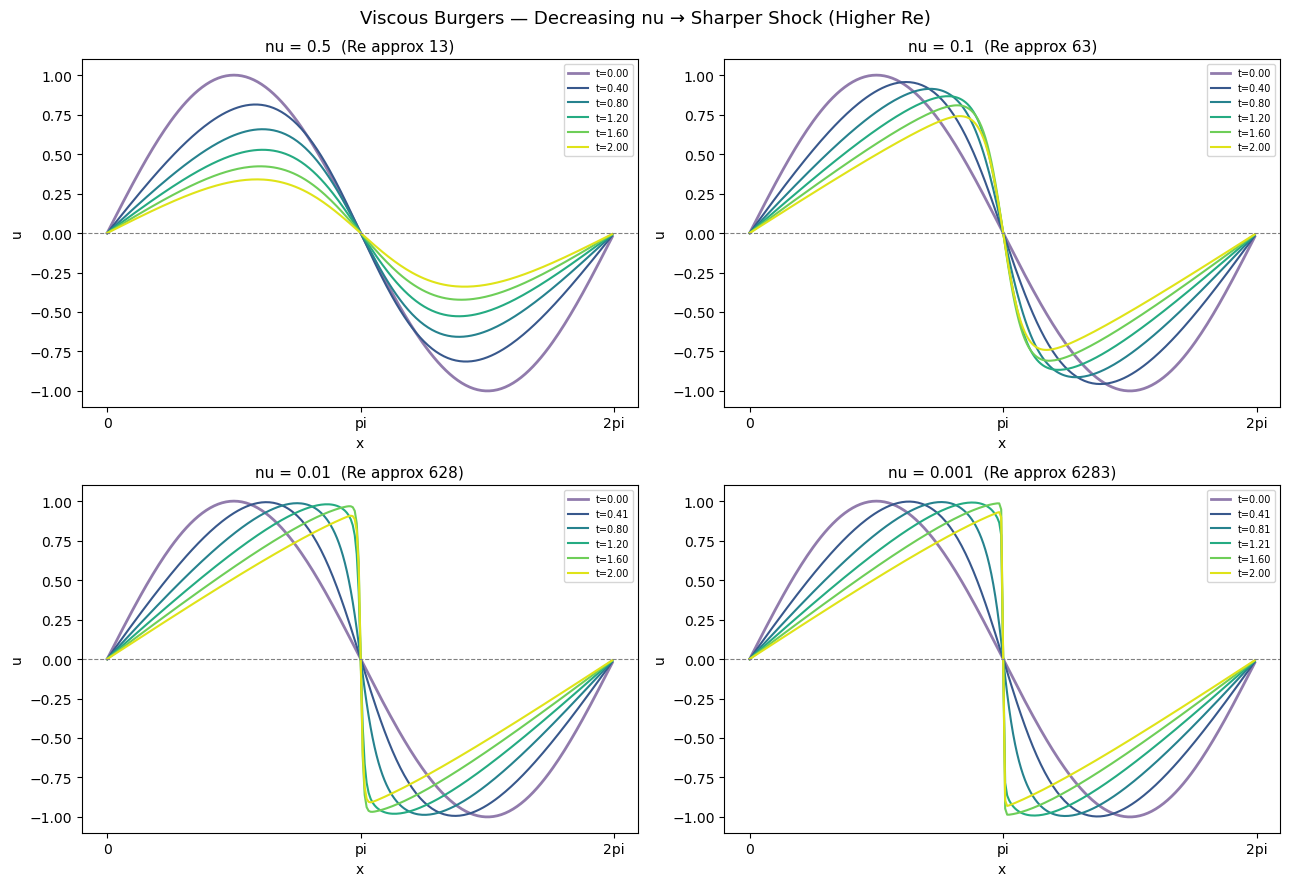

nu=0.5  (Re~13):   diffusion dominates — smooth spreading, no shock
nu=0.1  (Re~63):   gentle shock, well-resolved
nu=0.01 (Re~628):  sharp shock at x=pi — convection dominates
nu=0.001(Re~6283): very sharp shock — adaptive dt keeps it stable


In [10]:
def burgers_viscous(u0, dx, nu, T, cfl=0.5, save_count=5):
    """
    Viscous Burgers: du/dt + u*du/dx = nu * d2u/dx2
    - Convection: general upwind (explicit)
    - Diffusion:  central difference (explicit)
    - dt recomputed every step from current u_max (adaptive CFL)
      This prevents blow-up at high Re where the shock steepens.
    """
    u          = u0.copy()
    t          = 0.0
    snapshots  = [(0.0, u.copy())]
    save_times = np.linspace(0, T, save_count + 1)[1:]
    next_save  = 0

    while t < T - 1e-12:
        u_max   = max(np.max(np.abs(u)), 1e-8)
        dt_cfl  = cfl * dx / u_max
        dt_diff = 0.4 * dx**2 / nu if nu > 0 else np.inf
        dt      = min(dt_cfl, dt_diff, T - t)   # don't overshoot T

        u_left  = np.roll(u,  1)
        u_right = np.roll(u, -1)

        # Nonlinear convection — general upwind
        conv = (np.maximum(u, 0) * (u - u_left) +
                np.minimum(u, 0) * (u_right - u)) / dx

        # Diffusion — central difference
        diff = nu * (u_right - 2*u + u_left) / dx**2

        u  = u - dt * conv + dt * diff
        t += dt

        if next_save < len(save_times) and t >= save_times[next_save] - 1e-10:
            snapshots.append((t, u.copy()))
            next_save += 1

    return snapshots

# ── Compare four viscosity levels — watch shock sharpen as nu decreases ───────
T_end     = 2.0
nu_values = [0.5, 0.1, 0.01, 0.001]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, nu in zip(axes.flat, nu_values):
    snaps    = burgers_viscous(u0, dx, nu, T_end, save_count=5)
    Re       = 1.0 * L / nu
    colors_v = plt.cm.viridis(np.linspace(0.1, 0.95, len(snaps)))

    for (t_snap, u_snap), color in zip(snaps, colors_v):
        lw    = 2   if t_snap == 0 else 1.5
        alpha = 0.6 if t_snap == 0 else 1.0
        ax.plot(x, u_snap, color=color, lw=lw, alpha=alpha, label=f"t={t_snap:.2f}")

    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_title(f"nu = {nu}  (Re approx {Re:.0f})", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.set_xticks([0, np.pi, 2*np.pi]); ax.set_xticklabels(["0", "pi", "2pi"])
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Viscous Burgers — Decreasing nu → Sharper Shock (Higher Re)", fontsize=13)
plt.tight_layout(); plt.show()

print("nu=0.5  (Re~13):   diffusion dominates — smooth spreading, no shock")
print("nu=0.1  (Re~63):   gentle shock, well-resolved")
print("nu=0.01 (Re~628):  sharp shock at x=pi — convection dominates")
print("nu=0.001(Re~6283): very sharp shock — adaptive dt keeps it stable")

## 4. The Exact Solution (Hopf-Cole Transformation)

Burgers' equation has a rare analytical solution via the **Hopf-Cole transformation**:

$$u = -2\nu \frac{\partial}{\partial x}\ln\phi, \quad \text{where } \phi \text{ satisfies the heat equation}$$

For periodic initial condition $u_0(x) = \sin(x)$, the exact solution at time $t$ is:

$$u(x,t) = \frac{-2\nu \sum_{n=1}^{\infty} n\, a_n\, e^{-n^2\nu t}\sin(nx)}{\sum_{n=0}^{\infty} a_n\, e^{-n^2\nu t}\cos(nx)}$$

We compute this numerically using the first $M$ Fourier modes to validate our solver.

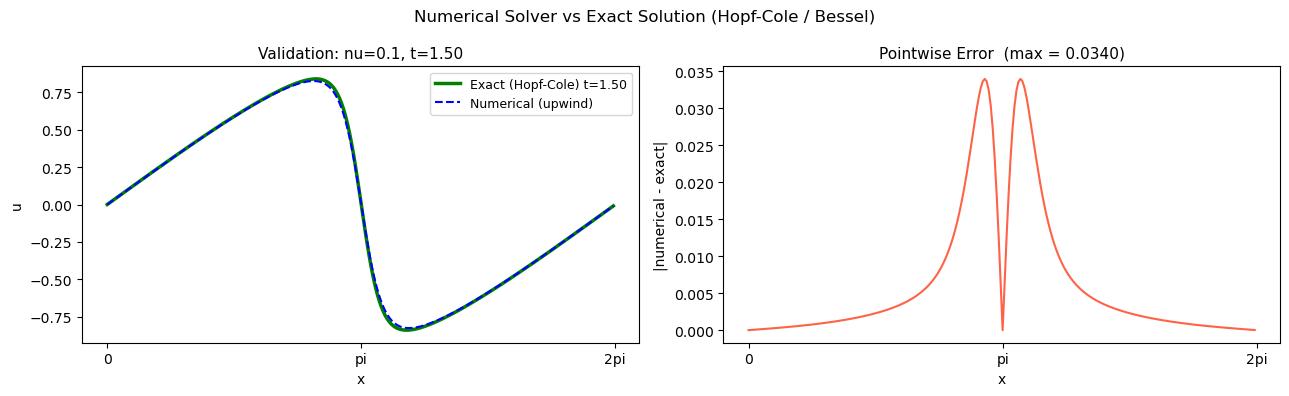

Max pointwise error = 0.033959
Error largest near the shock — expected for 1st-order upwind numerical diffusion.


In [11]:
from scipy.special import iv as bessel_iv   # modified Bessel function of 1st kind

def burgers_exact(x, t, nu, M=100):
    """
    Exact solution of viscous Burgers with u0 = sin(x) on [0, 2pi].

    Hopf-Cole transformation: u = -2*nu * d/dx ln(phi)
    phi0(x) = exp( cos(x)/(2*nu) ) = sum_n c_n cos(n*x)  using Bessel functions:
        phi0(x) = I_0(z) + 2 * sum_{n>=1} I_n(z) * cos(n*x),   z = 1/(2*nu)

    Result:
        u(x,t) = 4*nu * [sum_n n * I_n(z) * exp(-n^2*nu*t) * sin(n*x)]
                       / [I_0(z)  + 2 * sum_n I_n(z) * exp(-n^2*nu*t) * cos(n*x)]
    """
    z     = 1.0 / (2.0 * nu)
    n_arr = np.arange(1, M + 1)
    decay = np.exp(-n_arr**2 * nu * t)
    In    = bessel_iv(n_arr, z)   # I_1, I_2, ..., I_M
    I0    = float(bessel_iv(0, z))

    num = np.zeros_like(x, dtype=float)
    den = np.full_like(x, I0,  dtype=float)

    for i, n in enumerate(n_arr):
        num += n * In[i] * decay[i] * np.sin(n * x)
        den += 2 * In[i] * decay[i] * np.cos(n * x)

    return 4.0 * nu * num / den

# ── Validate ───────────────────────────────────────────────────────────────────
nu_val  = 0.1
T_val   = 1.5
snaps_v = burgers_viscous(u0, dx, nu_val, T_val, save_count=1)
t_final, u_numerical = snaps_v[-1]

u_ex  = burgers_exact(x, t_final, nu_val)
error = np.max(np.abs(u_numerical - u_ex))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x, u_ex,        "g-",  lw=2.5, label=f"Exact (Hopf-Cole) t={t_final:.2f}")
ax.plot(x, u_numerical, "b--", lw=1.5, label="Numerical (upwind)")
ax.set_title(f"Validation: nu={nu_val}, t={t_final:.2f}", fontsize=11)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.set_xticks([0, np.pi, 2*np.pi]); ax.set_xticklabels(["0", "pi", "2pi"])
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(x, np.abs(u_numerical - u_ex), "tomato", lw=1.5)
ax2.set_title(f"Pointwise Error  (max = {error:.4f})", fontsize=11)
ax2.set_xlabel("x"); ax2.set_ylabel("|numerical - exact|")
ax2.set_xticks([0, np.pi, 2*np.pi]); ax2.set_xticklabels(["0", "pi", "2pi"])

plt.suptitle("Numerical Solver vs Exact Solution (Hopf-Cole / Bessel)", fontsize=12)
plt.tight_layout(); plt.show()

print(f"Max pointwise error = {error:.6f}")
print("Error largest near the shock — expected for 1st-order upwind numerical diffusion.")

## 5. Summary — What Burgers' Teaches Us About Navier-Stokes

| Feature | Burgers' | Navier-Stokes |
|---------|---------|---------------|
| Nonlinear convection | $u\,\partial u/\partial x$ | $(\mathbf{u}\cdot\nabla)\mathbf{u}$ |
| Diffusion/viscosity | $\nu\,\partial^2 u/\partial x^2$ | $\nu\,\nabla^2\mathbf{u}$ |
| Reynolds number | $Re = UL/\nu$ | same |
| High Re | sharp shock | turbulence, thin boundary layers |
| Low Re | smooth spreading | laminar, diffusion-dominated |

**Key lessons from Burgers':**
1. **Nonlinearity steepens gradients** — the solution creates its own wave speed
2. **Shocks form in finite time** when $\nu = 0$ (or very small)
3. **Viscosity smooths shocks** — the sharper the shock, the more expensive to resolve
4. **Upwind is essential** for the convection term — central space is unstable here too
5. **Two stability conditions** must hold simultaneously: CFL ≤ 1 AND r ≤ 0.5
6. **Fine grids are needed at high Re** — the shock thickness scales as $\sim\nu$, so halving $\nu$ halves the required $\Delta x$